<a href="https://colab.research.google.com/github/yair-ytshaki/a_multi-class_classification_model_on_the_Fashion_MNIST/blob/main/Fashion_MNIST1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Author: Yair Ytshaki

###Description: This notebook implements and evaluates a multi-class classification model using the Pocket Perceptron algorithm on the Fashion MNIST dataset. It involves data preprocessing, training 10 one-vs-all binary classifiers, and assessing their performance with micro-averaged metrics and visualization of weight vector norms.

The Pocket Perceptron algorithm iteratively updates its weight vector $w$. When a misclassified point $(x_i, y_i)$ is found, the weight vector is updated using the rule:

$$w_{new} = w_{old} + y_i x_i$$

The in-sample error, $E_{in}(w)$, for a given weight vector $w$ is defined as the fraction of misclassified points on the training set:

$$E_{in}(w) = \frac{1}{N} \sum_{n=1}^{N} \mathbb{I}(\text{sign}(w^T x_n) \neq y_n)$$

where $N$ is the number of training examples, $\mathbb{I}(\cdot)$ is the indicator function, and $\text{sign}(w^T x_n)$ is the prediction made by the Perceptron.

In [ ]:
# imports
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import itertools
from tqdm import tqdm, trange
from tqdm.contrib import tzip
import time
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot'])
# %matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load dataset
(X_train_origin, Y_train_origin), (X_test_origin, Y_test_origin) = fashion_mnist.load_data()
X_train = X_train_origin.copy()
Y_train = Y_train_origin.copy()
X_test = X_test_origin.copy()
Y_test = Y_test_origin.copy()
print("Training set:", X_train.shape, Y_train.shape)
print("Test set:", X_test.shape, Y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


**EDA**

We chose to make this example and plot the images to see how the dataset looks like:

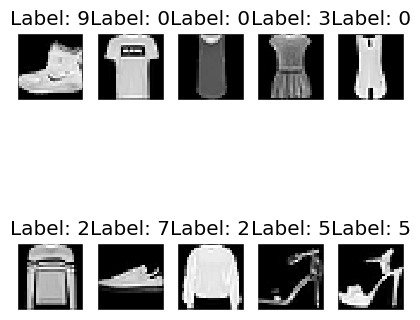

In [ ]:
# print 10 first items in X_train:
fig, axes = plt.subplots(2, 5, figsize=(5,5))
for i, ax in enumerate(axes.flatten()):             # no need for tqdm here
    ax.imshow(X_train[i], cmap='gray', interpolation='none')
    ax.set_title("Label: {}".format(Y_train[i]))
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

**Label and Image Transformation:**

We will plot every pixel value and later on we will comapre the normalize pixels to the origin.

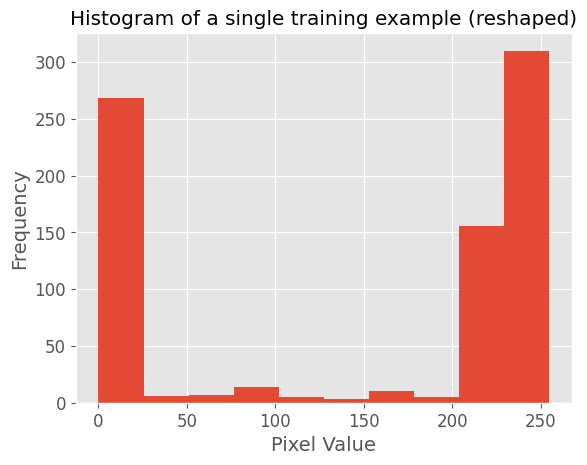

In [ ]:
example_image = X_train[7]
reshaped_example = example_image.reshape(-1) # Numpy effectively flattens the multi-dimensional array
                                                                        # into a 1-dimensional array
plt.hist(reshaped_example)
plt.title("Histogram of a single training example (reshaped)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

**Flattening Images and Normalizations**

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255
# ML models typically perform calculations using floating-point numbers.
# Converting to float32 ensures that the data is in the correct format for the
# model and can help with numerical stability during training.

# Normalizing by 255 scales these values to a range between 0 and 1. This is a
# common practice in image processing, because:
# It helps the optimization process converge faster.
# It prevents larger pixel values from dominating the learning process.
# It can improve the overall performance of the model.

# Add a column of ones for the bias term (The Bias Trick)
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# Example:
print("first sample shape: ", X_train[0].shape)
print("Augmented X shape: ",X_train.shape)

first sample shape:  (785,)
Augmented X shape:  (60000, 785)


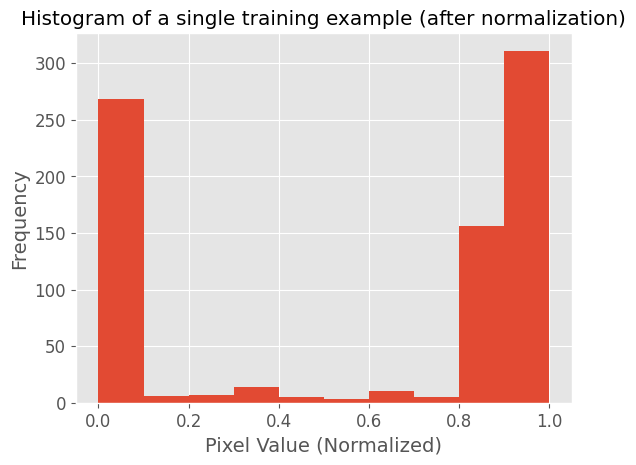

In [ ]:
# Example:
plt.hist(X_train[7])
plt.title("Histogram of a single training example (after normalization)")
plt.xlabel("Pixel Value (Normalized)")
plt.ylabel("Frequency")
plt.show()

So, we got the same plot, but normalized.

**One-Hot Encoding of Labels**

In [ ]:
n_classes = 10
print("Shape before one-hot encoding: ", Y_train.shape)

Y_train = np.zeros((Y_train_origin.shape[0], n_classes), dtype=np.float32)
Y_train[np.arange(Y_train_origin.shape[0]), Y_train_origin] = 1.0

Y_test = np.zeros((Y_test_origin.shape[0], n_classes), dtype=np.float32)
Y_test[np.arange(Y_test_origin.shape[0]), Y_test_origin] = 1.0

print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (60000,)
Shape after one-hot encoding:  (60000, 10)


Maybe next time we will choose to use df.getDummies(...) for one-hot encoding

Let's see if we got what we expected to have:

In [ ]:
print(Y_train_origin[7])
print(Y_train[7,:])

2
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


**Binary Classification Setup:**

In the first stage, we create a binary classifier **to distinguish between the '0' class and all other**
classes. We assign the label +1 to examples labeled '0' and -1 to examples labeled '1', '2', ..., '9'.
The weight vector obtained from this classification is denoted as $W^0$



In [ ]:
# This is an example:
# Create binary labels for '0' vs 'all others'
Y_train_binary = np.where(Y_train_origin == 0, 1, -1)
Y_test_binary = np.where(Y_test_origin == 0, 1, -1)

# Initialize the weight vector (w_0) for the binary classifier (0 vs others)
# The size should be equal to the number of features in X_train (including the bias term)
w_0 = np.zeros(X_train.shape[1])

print("Shape of Y_train_binary:", Y_train_binary.shape)
print("Shape of w_0 (initial weight vector):", w_0.shape)
print("Example of +1 label: Y_train_binary[2] =", Y_train_binary[2])

Shape of Y_train_binary: (60000,)
Shape of w_0 (initial weight vector): (785,)
Example of +1 label: Y_train_binary[2] = 1


**Iterative Binary Problems:**

The weight vectors resulting from these binary classifications are denoted as $W^1, W^2, ..., W^9$

We chose to implement by creating structural classes.

Following trials with 200, 300, and 400 iterations, 1000 iterations were selected, as the model showed progressive improvement. In the end of the notebook the learning rate of the model will be ploted.

In [ ]:
# define over-all variables
# The size should be equal to the number of features in X_train (including the bias term)
N_FEATURES = 785
# n_classes = 10
N_ITERATIONS = 1000

Note: *for a single vector or a batch matrix, np.dot(X, self.w) is the idiomatic and efficient way to compute $\mathbf{w}^T \mathbf{x}$ when $\mathbf{x}$ is defined as a row vector.

In [ ]:
class PocketPerceptron:
    """
    Pocket Perceptron Algorithm for binary classification, robust to
    non-linearly separable data by maintaining the best weight vector found.
    """
    def __init__(self, n_features, n_iterations):
        # Initialize weights (w) to zeros
        self.w = np.zeros(n_features)           # Current working weight vector (w_t)
        self.w_pocket = np.copy(self.w)         # Best weight vector found so far (w_pocket)
        self.best_error_count = float('inf')    # Error count for w_pocket
        self.n_iterations = n_iterations
        self.weights_history = []               # Store weights at each sampling interval
        self.errors_history = []               # Store 'best error' at each sampling interval

    def predict(self, X, weights=None):
        """Calculates the prediction using the specified or current weights."""
        if weights is None:
            weights = self.w # Default to the current working weights

        # The prediction is simply the sign of the dot product: w.T * X ,
        # where X is: (785,) when finding misclassified point, a single row X[i];
        # otherwise it is the (number_of_samples, number_of_features) matrix.
        linear_output = np.dot(X, weights) # note*
        # Use np.sign() to get +1 or -1 prediction. If 0, it defaults to 0.
        return np.sign(linear_output)


    def evaluate_error(self, X, y, weights):
        """Calculates the number of misclassifications for a given weight vector."""
        predictions = self.predict(X, weights) # output: (
        # Count where target label y does NOT equal the prediction
        error_count = np.sum(predictions != y) # for example: (0 != +1)
        return error_count


    # here we will get y as Y_train_binary (+1 or -1) , X is the augmented data (e.g., 60000 x 785), out X_train
    def fit(self, X, y):
        """Trains the perceptron with the pocket algorithm."""

        # --- Initialization Step (t=0): ---
        # Set the initial pocket weight vector based on initial w (all zeros).
        # We must calculate the error for the initial w.
        self.best_error_count = self.evaluate_error(X, y, self.w_pocket)
        print(f"Initial Error Count: {self.best_error_count}")

        # PLA runs for one update to obtain w_t+1
        for iteration in trange(self.n_iterations):
            # --- PLA Step: Find one misclassified point and update w ---

            # Find all misclassified points
            predictions = self.predict(X, self.w)
            # finds the indices that the current Perceptron weight vector (self.w) classified incorrectly.
            misclassified_indices = np.where(predictions != y)[0] # Example:
            # np.where([False, True, True]) returns (array([1, 2]),), and [0] returns the
            # first and only element array([1, 2]), since its 1D.

            if len(misclassified_indices) == 0:
                print(f"Current PLA vector converged at iteration {iteration + 1}.")
                # Since the current w is perfect, it is the best, and we can stop
                self.w_pocket = np.copy(self.w)
                self.best_error_count = 0
                break

            # Randomly pick one misclassified point (standard PLA procedure)
            i = np.random.choice(misclassified_indices)
            xi, target = X[i], y[i]

            # Run PLA for one update (w_new = w_old + y*x)
            self.w += (target * xi) # w is now w_t+1

            # --- Pocket Algorithm Step: Evaluation and Update ---

            # Evaluate the performance of the new current weight vector (w_t+1)
            current_error_count = self.evaluate_error(X, y, self.w)

            # If current_error_count is better than best_error_count, update the pocket
            if current_error_count < self.best_error_count:
                # Set w_pocket to w (w_pocket <--- w_t+1)
                self.w_pocket = np.copy(self.w)
                self.best_error_count = current_error_count
                print(f"  Pocket updated: Iteration {iteration + 1} with error count {current_error_count}")

            if (iteration % 100 == 0):
                # Store a copy of the current best weights
                self.weights_history.append(self.w_pocket.copy())
                # Store a copy of the current best error_count
                self.errors_history.append(self.best_error_count)

        # # Add the best weight vector found to weights_history
        # self.weights_history.append(self.w_pocket.copy())  -- we will pass this
        # because I will take iterations that are multiples of 100.

        # Return the best weight vector found (and maybe the best error_count)
        return self.w_pocket, self.weights_history, self.errors_history

# --- End of PocketPerceptron Class ---

**One-vs-All Training Loop:**

In [ ]:
# Dictionary to store the 10 trained Perceptron objects
# Each Perceptron object will contain its weights and error history attribute in order to plot the learning rate
trained_classifiers = {}
w_history = {}
error_history = {}

# K=10 classes (digits 0 through 9)
for class_label in tqdm(range(n_classes)):
    print(f"Training One-vs-All classifier for class {class_label}...")

    # --- Step 1: Create Binary Labels (One-vs-All) ---
    # --- (+1 for current class, -1 for all others) ---
    Y_train_binary = np.where(Y_train_origin == class_label, 1, -1)

    # --- Step 2: Initialize and Train the Binary Pocket Perceptron ---

    # Create a new Perceptron model for this specific binary problem
    model = PocketPerceptron(n_features=N_FEATURES, n_iterations=N_ITERATIONS)

    # Train the model
    best_w, w_hist, err_hist = model.fit(X_train, Y_train_binary)

    # Store the trained model and the weights and error history
    trained_classifiers[class_label] = best_w
    w_history[class_label] = w_hist
    error_history[class_label] = err_hist

print("\nTraining complete. Stored 10 Perceptron models with weight histories.")
# --- End of Training ---

  0%|          | 0/10 [00:00<?, ?it/s]

Training One-vs-All classifier for class 0...
Initial Error Count: 60000



  0%|          | 2/1000 [00:00<00:56, 17.57it/s]

  Pocket updated: Iteration 1 with error count 6000



  1%|          | 8/1000 [00:00<00:58, 16.90it/s]

...

  Pocket updated: Iteration 898 with error count 856



 92%|█████████▏| 918/1000 [01:07<00:06, 13.52it/s]

  Pocket updated: Iteration 916 with error count 848



100%|██████████| 10/10 [11:38<00:00, 69.88s/it]


Training complete. Stored 10 Perceptron models with weight histories.


**Prediction:**

$\hat y=argmax_y (W^y*X$)

In [ ]:
def multi_class_prediction(X, classifiers):
  """
    Makes multi-class predictions by selecting the classifier with the highest activation score.
    Input: X_test (?? , 765), and (trained) classifiers (dict)
    Output: y_pred (??,)
  """
  # Create a matrix of all 10 weight vectors (10 x 785)
  W_matrix = np.array([classifiers[n] for n in range(n_classes)])

  # Calculate all 10 activation scores for every input example
  scores = np.dot(X, W_matrix.T)   # Scores shape: (N_examples x 10)

  # The prediction is the index (class label) of the maximum score
  return np.argmax(scores, axis=1) # If axis=1, it returns the *_index_* of the maximum along the row.
  # Output: (??,) which is y_pred

**Model Evaluation:**

In [ ]:
def stats(y_true, y_pred):
  """
      Calculates micro-averaged performance metrics for a multi-class classification problem.
      input: y_true (array-like): True labels, y_pred (array-like): Predicted labels.
      output: TN, FP, FN, TP, Se, Sp, PPV, NPV, Acc, F1 (all micro-averaged),
              and class_sensitivities (array of sensitivities for each class).
  """
  cm = confusion_matrix(y_true, y_pred) # The function returns a NumPy array representing the confusion matrix
  num_classes = n_classes # Using the global n_classes (10)
  total_samples = len(y_true)

  TP_sum = 0
  FP_sum = 0
  FN_sum = 0
  TN_sum = 0

  class_TPs = np.zeros(num_classes)
  class_FNs = np.zeros(num_classes)
  class_sensitivities = np.zeros(num_classes)

  for i in trange(num_classes):
      # One-vs-Rest calculation for class i
      tp = cm[i, i]
      fp = np.sum(cm[:, i]) - tp  # Sum of column i (predicted as i) - true positive i
      fn = np.sum(cm[i, :]) - tp  # Sum of row i (actual i) - true positive i
      tn = total_samples - (tp + fp + fn) # Total samples - (TP_i + FP_i + FN_i)

      TP_sum += tp
      FP_sum += fp
      FN_sum += fn
      TN_sum += tn

      class_TPs[i] = tp
      class_FNs[i] = fn
      class_sensitivities[i] = tp / (tp + fn) if (tp + fn) > 0 else 0

  # Assign micro-averaged components
  TP = TP_sum
  FP = FP_sum
  FN = FN_sum
  TN = TN_sum

  # Calculate metrics using the provided formulas
  # Handle division by zero for robustness
  Se = TP / (TP + FN) if (TP + FN) > 0 else 0
  Sp = TN / (TN + FP) if (TN + FP) > 0 else 0
  PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
  NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
  Acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
  F1 = (2*Se*PPV) / (Se+PPV) if (Se+PPV) > 0 else 0

  return TN, FP, FN, TP, Se, Sp, PPV, NPV, Acc, F1, class_sensitivities

100%|██████████| 10/10 [00:00<00:00, 36472.21it/s]


Performance metrics:


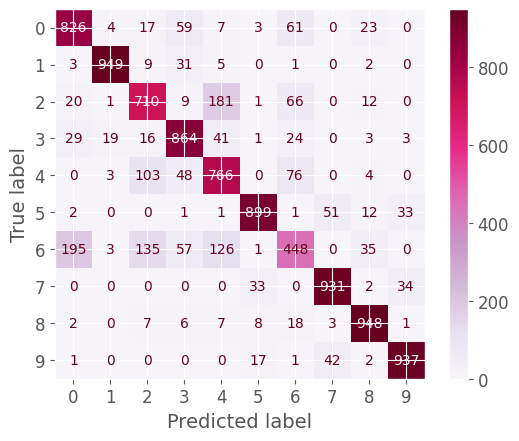

Performance metrics - micro-averaged:
Sensitivity is 0.8278. 
Specificity is 0.9809. 
PPV is 0.83. 
NPV is 0.9809. 
Accuracy is 0.9656. 
F1 is 0.8278. 

Sensitivity for each class (True Positive Rate, TPR):
Class 0: 0.8260
Class 1: 0.9490
Class 2: 0.7100
Class 3: 0.8640
Class 4: 0.7660
Class 5: 0.8990
Class 6: 0.4480
Class 7: 0.9310
Class 8: 0.9480
Class 9: 0.9370


In [ ]:
y_pred = multi_class_prediction(X_test, trained_classifiers)

# Calculate Stats:
TN, FP, FN, TP, Se, Sp, PPV, NPV, Acc, F1, class_sensitivities = stats(Y_test_origin, y_pred)
print("Performance metrics:")

ConfusionMatrixDisplay.from_predictions(Y_test_origin, y_pred, cmap='PuRd')
plt.title("")
plt.show()

print("Performance metrics - micro-averaged:")
print('Sensitivity is {:.4f}. \nSpecificity is {:.4f}. \nPPV is {:.2f}. \nNPV is {:.4f}. \nAccuracy is {:.4f}. \nF1 is {:.4f}. '
.format(Se,Sp,PPV,NPV,Acc,F1))

print("\nSensitivity for each class (True Positive Rate, TPR):")
for i, sens in enumerate(class_sensitivities):
    print(f"Class {i}: {sens:.4f}")

Discussions:
1. The model’s overall accuracy (as the proportion of correctly classified samples out of all test samples) is: 96.56%. we can valid our result by taking a quick look at the GitHub "repo" of the MNIST, where it been said that "Classic machine learning algorithms can also achieve 97% easily".

2. As reflected in the confusion matrix, there are several classes that are much harder to classify by our model. We can see it by looking at thier poor model's sensetivity rate. The hardest categories of clothes to classify are:
6 shirt, 2 pullover, 4 coat, 0 t-shirts/top, which gained: 44.8%, 71.0%, 76.6%, 82.6% respectively, while the rest got 86.4% and above. **

3. From our perspective, it makes sense that the model will be confused by these specific classes, because they are all look the same in general: they cover the upper body and have the sleeves. Furtheremore, the shape of the black pixels is relatively similar for these items. For example, if we take a shoe, its shape will be drastically different from the one a t-shirt has.

**(2.) The easiest to classify are the trousers (94.9%), and right after are the bags (94.8%). These results make sense as well, because of the same reason we mentioned: there are no other items that are look similer to the bag or the trouser.

L2 norms calculated for all classifiers.


/tmp/ipykernel_1739/642933546.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10') # 'tab10' provides 10 distinct colors


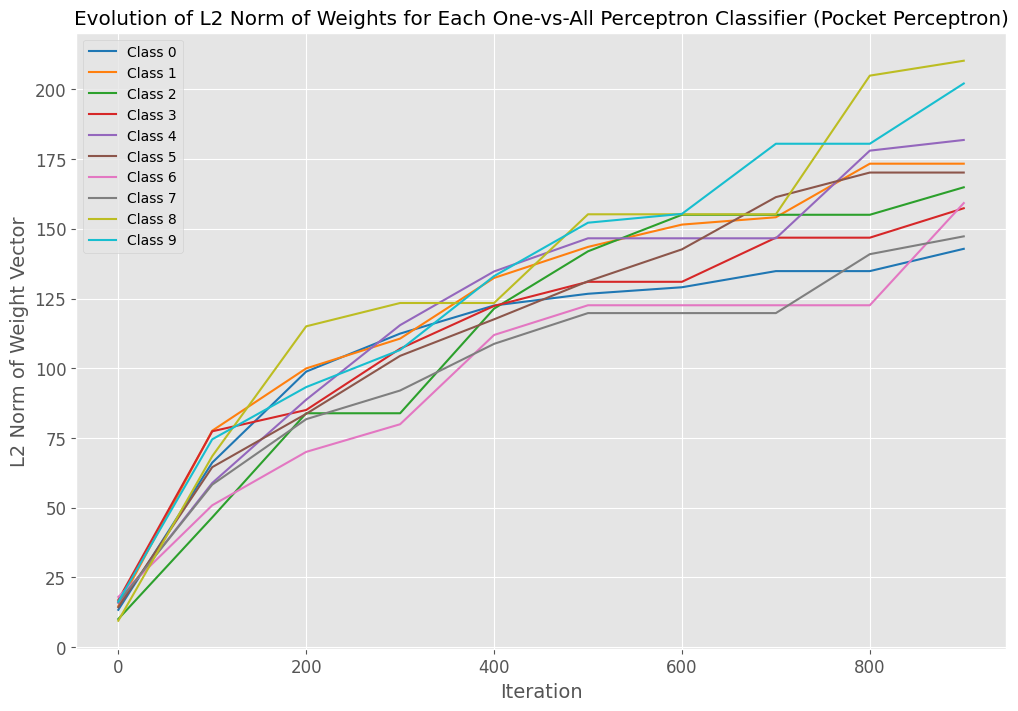

In [ ]:
#@title: weights learning rate cell
# Calculate L2 norms for the weights history of each classifier

l2_norms_history = {}

for class_label, history in w_history.items():
    # Calculate L2 norm for each weight vector in the history
    # np.linalg.norm(w) computes the L2 norm (Euclidean norm) by default
    norms = [np.linalg.norm(w_vector) for w_vector in history]
    l2_norms_history[class_label] = norms

print("L2 norms calculated for all classifiers.")
# Example for class 0:
# print(f"L2 norms for class 0: {l2_norms_history[0][:5]}...")

# Plot the L2 norms of the weights over iterations
plt.figure(figsize=(12, 8))

# Generate iteration labels for the x-axis
# The weights were sampled every 100 iterations, starting from iteration 0.
# The number of samples is len(l2_norms_history[class_label]), so iterations
# are [0, 100, 200, ...]
# Account for the possibility that the last iteration might not be a multiple
# of 100  (not needed for 1000 iteration)
num_samples = len(list(l2_norms_history.values())[0])
iterations = np.arange(num_samples) * 100

# Get a colormap with enough distinct colors for all classes
colors = plt.cm.get_cmap('tab10') # 'tab10' provides 10 distinct colors

for class_label, norms in l2_norms_history.items():
    plt.plot(iterations, norms, label=f'Class {class_label}', color=colors(class_label))

plt.title('Evolution of L2 Norm of Weights for Each One-vs-All Perceptron Classifier (Pocket Perceptron)')
plt.xlabel('Iteration')
plt.ylabel('L2 Norm of Weight Vector')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Discussions:


As reflected from the plot, the Norm of (the best) Weights for each Perceptron classifier is getting bigger along the iterations. It generally indicates that the learning algorithm is making more significant adjustments to the weight vector:

The Perceptron algorithm updates its weights (w) by adding y*x (where y is the true label and x is the input vector), whenever it encounters a misclassified point. If y@x has a component in the same direction as the current w, adding it will increase the magnitude of w. So, an increasing norm suggests the model is actively learning and adjusting its decision boundary to correct misclassifications it encounters.

The differences in L2 norms arise from the specific learning process for each one-vs-all problem, reflecting how strongly the model had to emphasize certain features to classify each respective class. An increasing L2 norm indicates that the algorithm is making more significant adjustments to the weight vector. The initial definition of all weight vectors as zeros does not cause the final differences in their L2 norms after 1000 iterations.

It is difficult to determine from this plot whether our assumption about the model confusing certain items holds here, so we will examine the best error count for each classifier in a later plot.

*Note: The plot shows 900 iterations because the initial weight definitions were not entered into the dictionary. We discovered this after the model's training session had finished, and we decided not to retrain it, since the trend was already clearly demonstrated.

### Evolution of Best Error Count for Each One-vs-All Classifier

/tmp/ipykernel_1739/3162293074.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')


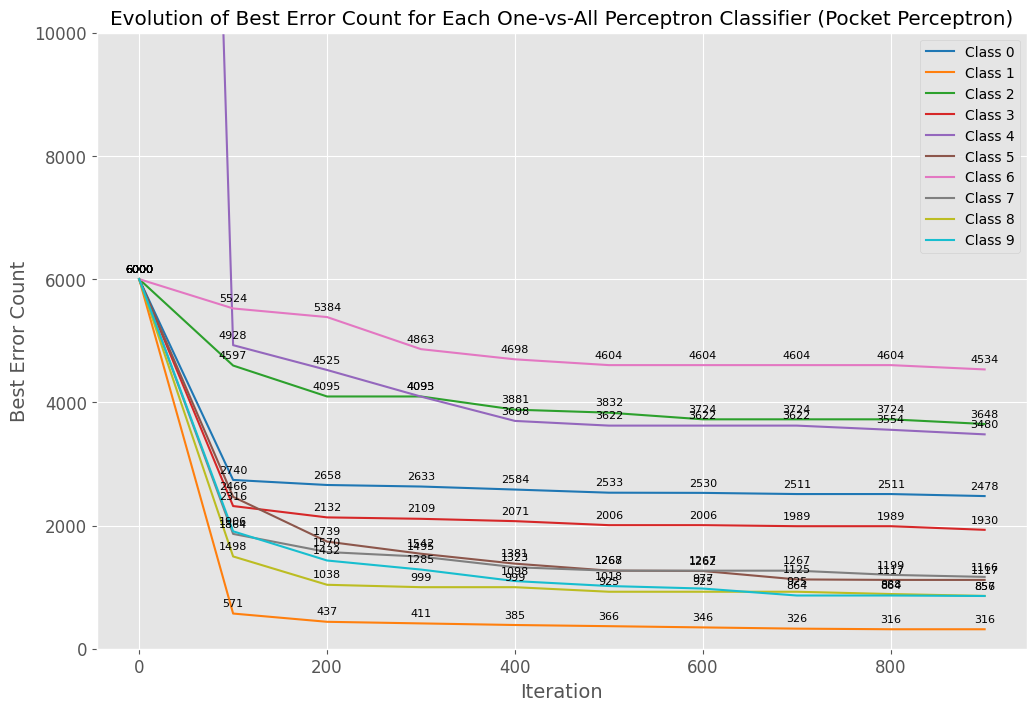

In [ ]:
plt.figure(figsize=(12, 8))

num_samples = len(list(error_history.values())[0])
iterations = np.arange(num_samples) * 100

# Get a colormap with enough distinct colors for all classes
colors = plt.cm.get_cmap('tab10')

for class_label, errors in error_history.items():
    plt.plot(iterations, errors, label=f'Class {class_label}', color=colors(class_label))
    for i, err_count in enumerate(errors):
        plt.annotate(str(err_count), (iterations[i], errors[i]),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.title('Evolution of Best Error Count for Each One-vs-All Perceptron Classifier (Pocket Perceptron)')
plt.xlabel('Iteration')
plt.ylabel('Best Error Count')
plt.ylim(0, 10000) # Set y-axis limit to 10,000
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Discussions:

The plot directly visualizes the training performance of each one-vs-all classifier over iterations. It shows the lowest number of misclassified samples found by the Pocket Perceptron algorithm up to that point in training. This plot is an indicator of the learning rate, because it quantitatively demonstrates how the model reduces its errors. A steep downward trend signifies learning, while a flattening curve suggests convergence or a slower learning process.

* We can observe that after approximately 500 iterations, the best error count for all classifiers shows little change compared to the error counts in earlier iterations.
* The results shown in this graph are consistent with our discussion of the sensitivity rates: the model predicts trousers most easily, while it struggles to classify shirts and pullovers correctly, as reflected in the best error counts.